### Importation des modules

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact, Dropdown

### Chargement et ouverture du tableau d'informations fixes sur les chiens

In [16]:
# Optionnel mais pratique pour l'affichage dans Jupyter
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

# 1. Charger les informations des chiens
df_dogs = pd.read_excel(r"C:\Users\Cours APT\Documents\dog-behavior-analysis\data\DogInfo.xlsx")
print(f"Nombre de chiens : {len(df_dogs)}")
display(df_dogs.head())

Nombre de chiens : 45


,DogID,Breed,Weight,Age months,Gender,NeuteringStatus
0,16,Crossbreed,13,20,1,0
1,18,Belgian Shepherd,29,76,2,0
2,19,German Shepherd,30,57,1,0
3,20,Border Collie,15,47,1,0
4,21,Golden Retriever,39,19,2,0


### Chargement du CSV contenant les comportements et les séries temporelles relatives à chaque ? chien

In [25]:
# Option 1 : Moteur standard Pandas (Recommandé pour charger juste 'nrows' lignes)
na_values = ['<undefined>']

df_ts_sample = pd.read_csv(
    r"C:\Users\Cours APT\Documents\dog-behavior-analysis\data\DogMoveData.csv", 
    na_values=na_values
)

print(f"Dimensions de l'échantillon : {df_ts_sample.shape}")
display(df_ts_sample.head())

C:\Users\Cours APT\AppData\Local\Temp\ipykernel_18300\417272739.py:4: DtypeWarning: Columns (0: Behavior_2, 1: Behavior_3, 2: PointEvent) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ts_sample = pd.read_csv(


Dimensions de l'échantillon : (10611068, 20)


,DogID,TestNum,t_sec,ABack_x,ABack_y,ABack_z,ANeck_x,ANeck_y,ANeck_z,GBack_x,GBack_y,GBack_z,GNeck_x,GNeck_y,GNeck_z,Task,Behavior_1,Behavior_2,Behavior_3,PointEvent
0,16,1,0.00,0.041504,0.938965,-0.015137,-0.067871,-0.510254,-0.934570,-17.639161,-22.766115,7.446290,-7.934571,6.347657,13.427735,NaN,NaN,NaN,NaN,NaN
1,16,1,0.01,0.041992,0.941895,-0.020020,-0.128906,-0.494141,-0.913086,-15.075685,-11.413575,4.821778,-3.906250,4.394532,16.540528,NaN,Synchronization,NaN,NaN,NaN
2,16,1,0.02,0.040527,0.939453,-0.004395,-0.158691,-0.480469,-0.911133,-12.207032,-0.122070,2.807617,-0.488281,-1.953125,26.794435,NaN,Synchronization,NaN,NaN,NaN
3,16,1,0.03,0.021484,0.946289,0.007813,-0.122070,-0.486816,-0.880371,-9.460450,7.995606,1.586914,1.159668,-5.676270,38.085940,NaN,Synchronization,NaN,NaN,NaN
4,16,1,0.04,-0.000977,0.951172,0.033691,-0.053711,-0.500000,-0.807129,-8.361817,14.587403,-1.037598,4.577637,4.089356,41.503909,NaN,Synchronization,NaN,NaN,NaN


### Évaluation des données manquantes (labels)

In [37]:
# Analyser le taux de valeurs manquantes par colonne
missing_rates = df_ts_sample.isnull().mean() * 100
print("Pourcentage de valeurs manquantes dans les séries temporelles :")
print(missing_rates[missing_rates > 0].sort_values(ascending=False))

# Regarder quels sont les comportements uniques annotés (hors NaN)
print("\nComportements uniques dans Behavior_1 :")
print(df_ts_sample['Behavior_1'].value_counts(dropna=False))

Pourcentage de valeurs manquantes dans les séries temporelles :
PointEvent    99.753342
Behavior_3    98.104960
Behavior_2    71.940770
Behavior_1    38.047056
Task          24.434402
dtype: float64

Comportements uniques dans Behavior_1 :
Behavior_1
NaN                      4037199
Lying chest              1031301
Sniffing                 1026178
Playing                   862571
Panting                   836062
Walking                   728930
Trotting                  717593
Sitting                   509412
Standing                  448691
Eating                    166210
Pacing                     77104
Drinking                   64721
Shaking                    41234
Carrying object            17951
Synchronization            16755
Tugging                    13664
Galloping                  10828
Jumping                     3859
Bowing                       518
Extra_Synchronization        287
Name: count, dtype: int64


### Fusion et visualisation d'une série temporelle

In [ ]:
# Liste dynamique des IDs de chiens et numéros de test disponibles
available_dogs = sorted(df_ts_sample['DogID'].unique())
available_tests = sorted(df_ts_sample['TestNum'].unique())

# Dictionnaire des capteurs disponibles (le texte à gauche s'affiche, la valeur à droite est utilisée dans le code)
available_sensors = {
    'Accéléromètre Dos (ABack)': 'ABack',
    'Accéléromètre Cou (ANeck)': 'ANeck',
    'Gyroscope Dos (GBack)': 'GBack',
    'Gyroscope Cou (GNeck)': 'GNeck'
}

def tracer_series_chien(dog_id, test_num, sensor):
    df_merged = pd.merge(df_ts_sample, df_dogs, on='DogID', how='left')
    
    mask = (df_merged['DogID'] == dog_id) & (df_merged['TestNum'] == test_num)
    df_plot = df_merged[mask].copy()

    if df_plot.empty:
        print(f"⚠️ Aucune donnée disponible pour DogID {dog_id} et TestNum {test_num}.")
        return

    breed_name = df_plot['Breed'].iloc[0] if 'Breed' in df_plot.columns else ""

    fig, ax1 = plt.subplots(figsize=(15, 6))

    # Tracé dynamique des 3 axes (x, y, z) en fonction du capteur choisi
    ax1.plot(df_plot['t_sec'], df_plot[f'{sensor}_x'], label=f'{sensor}_x', alpha=0.7)
    ax1.plot(df_plot['t_sec'], df_plot[f'{sensor}_y'], label=f'{sensor}_y', alpha=0.7)
    ax1.plot(df_plot['t_sec'], df_plot[f'{sensor}_z'], label=f'{sensor}_z', alpha=0.7)

    # Adaptation dynamique du label de l'axe Y (Accélération pour 'A', Vitesse angulaire pour 'G')
    y_label = "Accélération (g)" if sensor.startswith('A') else "Vitesse angulaire"
    
    ax1.set_title(f"Signaux {sensor} et Comportements - DogID {dog_id} ({breed_name}) - Test {test_num}")
    ax1.set_xlabel("Temps (secondes)")
    ax1.set_ylabel(y_label)
    ax1.legend(loc='upper left')

    ax2 = ax1.twinx()

    styles = {
        'Behavior_1': {'color': 'red', 'marker': 'o'},
        # 'Behavior_2': {'color': 'blue', 'marker': 'x'},
        # 'Behavior_3': {'color': 'green', 'marker': 's'}
    }

    has_behavior = False

    for col, style in styles.items():
        df_annotated = df_plot.dropna(subset=[col])
        
        if not df_annotated.empty:
            ax2.scatter(df_annotated['t_sec'], df_annotated[col], 
                        color=style['color'], marker=style['marker'], s=40, 
                        label=col, zorder=5, alpha=0.8)
            has_behavior = True

    if has_behavior:
        ax2.set_ylabel("Comportements")
        ax2.legend(loc='upper right')
    else:
        print(f"⚠️ Aucun comportement annoté dans ce segment pour le chien {dog_id}.")

    plt.grid(False)
    plt.show()

# Interface interactive avec 3 menus déroulants
interact(tracer_series_chien, 
         dog_id=Dropdown(options=available_dogs, description='DogID:'), 
         test_num=Dropdown(options=available_tests, description='TestNum:'),
         sensor=Dropdown(options=available_sensors, description='Capteur:'));

interactive(children=(Dropdown(description='DogID:', options=(np.int64(16), np.int64(18), np.int64(19), np.int…

### Inventaire des jeux de données

In [38]:
# Fonction pour générer un résumé de la structure d'un DataFrame
def analyse_colonnes(df, nom_dataset):
    print(f"=== Vue d'ensemble du jeu de données : {nom_dataset} ===")
    print(f"Nombre total de lignes : {len(df)}")
    print(f"Nombre total de colonnes : {df.shape[1]}")
    
    # Vérification et décompte des séries temporelles uniques (DogID + TestNum)
    if {'DogID', 'TestNum'}.issubset(df.columns):
        nb_series = df.groupby(['DogID', 'TestNum']).ngroups
        print(f"Nombre de séries temporelles uniques (DogID x TestNum) : {nb_series}")
    
    # Création d'un tableau récapitulatif
    resume = pd.DataFrame({
        'Valeurs renseignées': df.count(),               # Nombre de valeurs non nulles
        'Valeurs manquantes': df.isnull().sum(),         # Nombre de NaN
        'Valeurs uniques': df.nunique(dropna=True),      # Nombre de valeurs uniques (hors NaN)
        'Type de donnée': df.dtypes                      # Type (int, float, object...)
    })
    
    # Affichage du tableau
    display(resume)
    print("-" * 50 + "\n")

# 1. Analyse du fichier des informations sur les chiens
analyse_colonnes(df_dogs, "Informations Chiens (df_dogs)")

# 2. Analyse de l'échantillon des séries temporelles
analyse_colonnes(df_ts_sample, "Séries Temporelles (df_ts_sample)")

=== Vue d'ensemble du jeu de données : Informations Chiens (df_dogs) ===
Nombre total de lignes : 45
Nombre total de colonnes : 6


,Valeurs renseignées,Valeurs manquantes,Valeurs uniques,Type de donnée
DogID,45,0,45,int64
Breed,45,0,26,str
Weight,45,0,21,int64
Age months,45,0,38,int64
Gender,45,0,2,int64
NeuteringStatus,45,0,2,int64


--------------------------------------------------

=== Vue d'ensemble du jeu de données : Séries Temporelles (df_ts_sample) ===
Nombre total de lignes : 10611068
Nombre total de colonnes : 20
Nombre de séries temporelles uniques (DogID x TestNum) : 62


,Valeurs renseignées,Valeurs manquantes,Valeurs uniques,Type de donnée
DogID,10611068,0,45,int64
TestNum,10611068,0,2,int64
t_sec,10611068,0,217656,float64
ABack_x,10611068,0,199179,float64
ABack_y,10611068,0,219338,float64
ABack_z,10611068,0,174512,float64
ANeck_x,10611068,0,252896,float64
ANeck_y,10611068,0,259884,float64
ANeck_z,10611068,0,238637,float64
GBack_x,10611068,0,175824,float64


--------------------------------------------------



### Visualisation des effectifs des caractéristiques

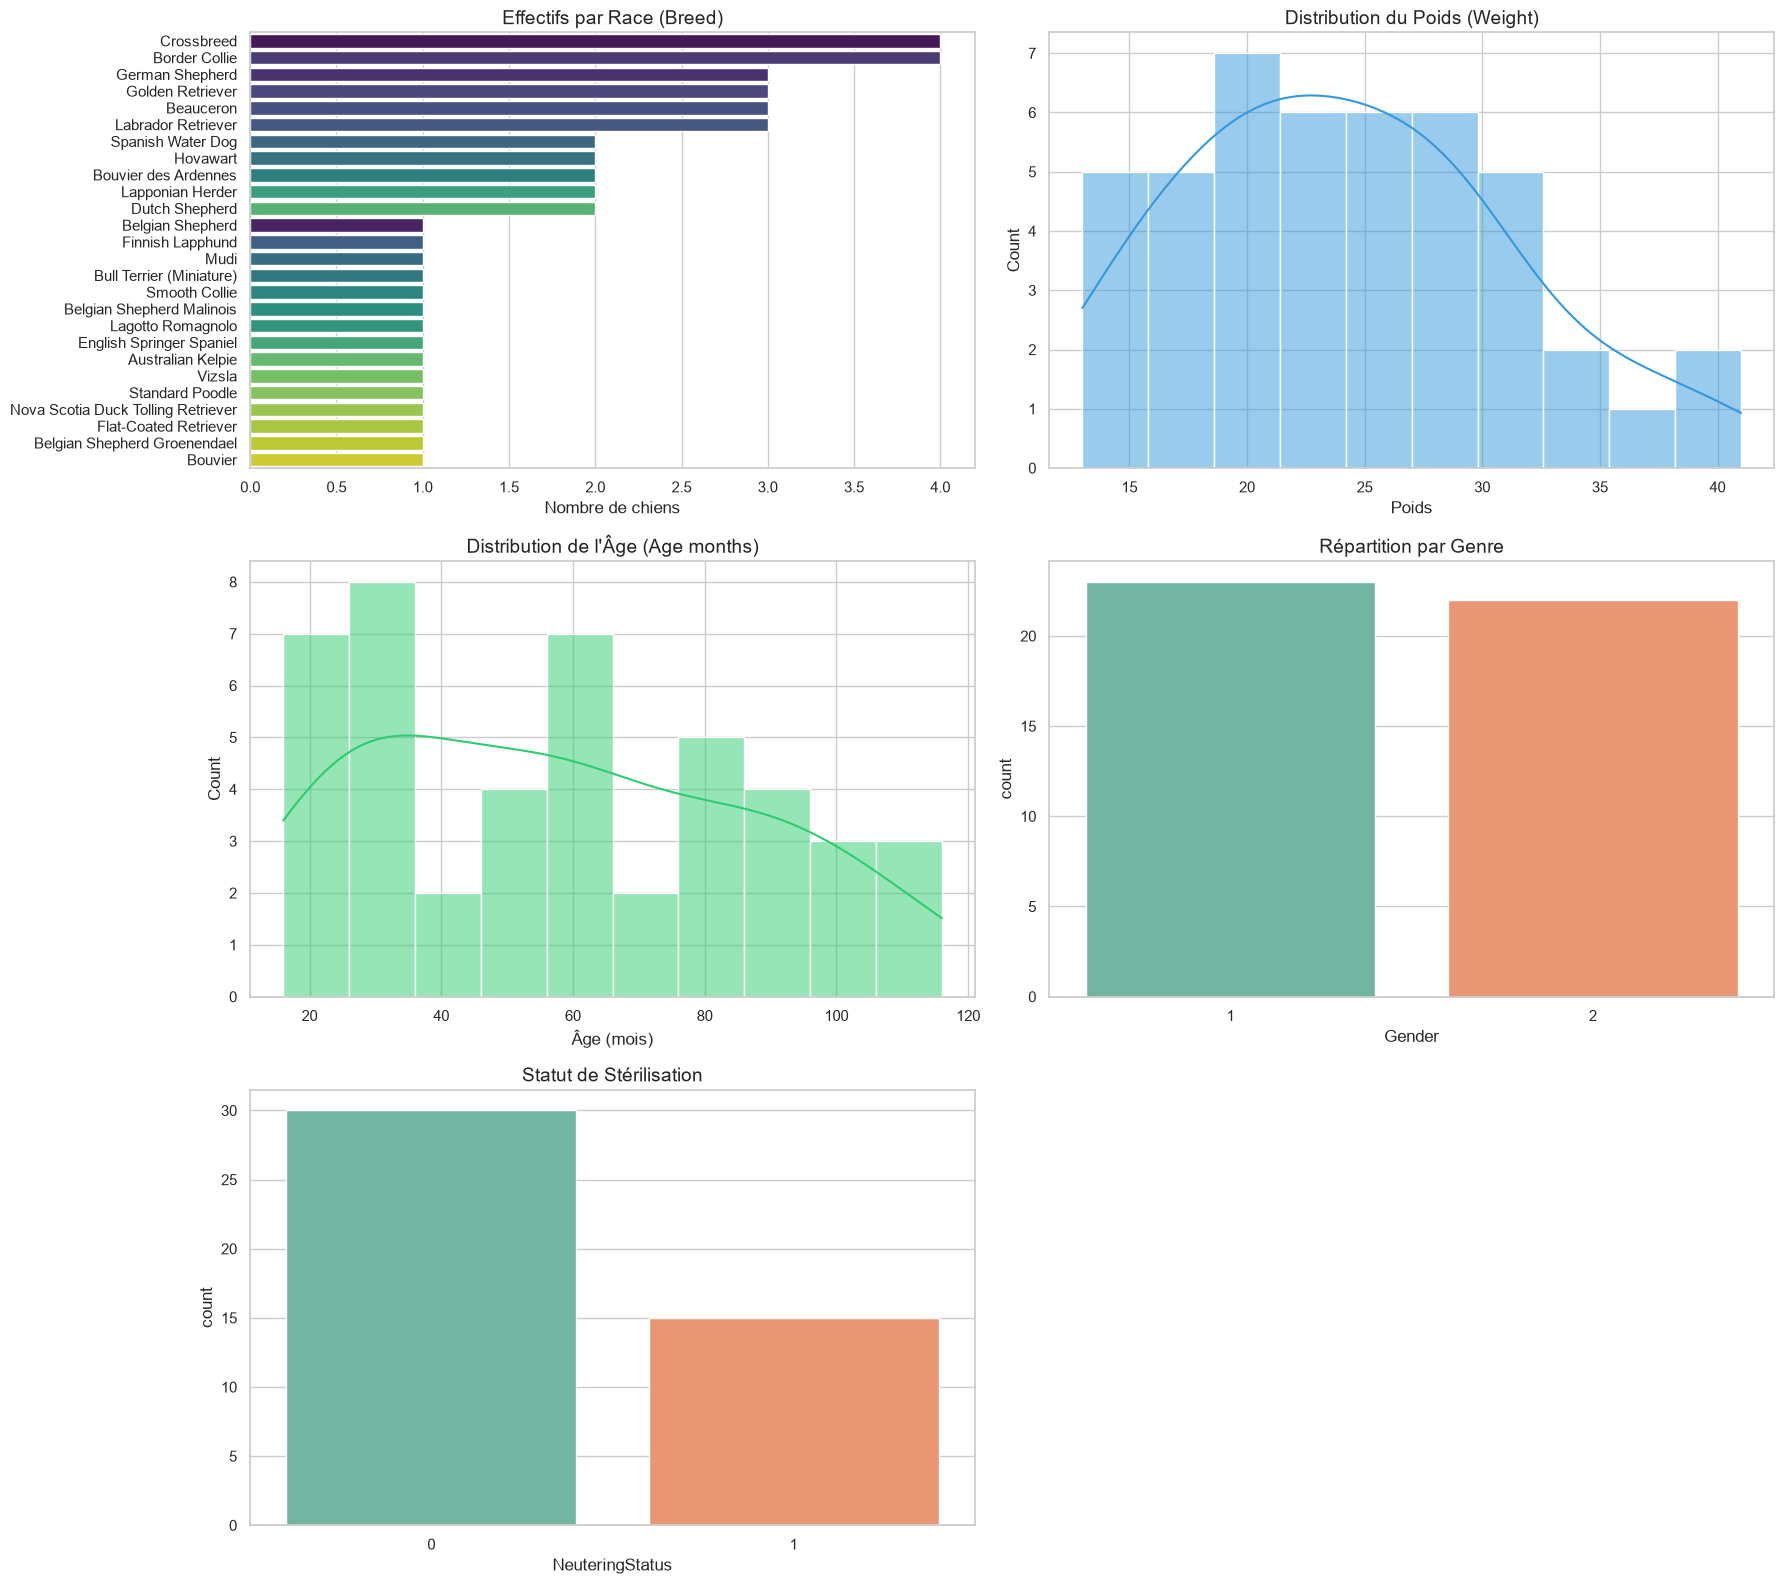

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration du style visuel
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
axes = axes.flatten() # Permet d'itérer facilement sur les sous-graphiques

# 1. Breed (Race) - Barres horizontales car beaucoup de catégories
sns.countplot(
    data=df_dogs, 
    y='Breed',
    hue='Breed',                # Ajout de hue pour éliminer le warning
    legend=False,              # Desactive la légende redondante
    order=df_dogs['Breed'].value_counts().index, 
    ax=axes[0], 
    palette="viridis"
)
axes[0].set_title("Effectifs par Race (Breed)", fontsize=14)
axes[0].set_xlabel("Nombre de chiens")
axes[0].set_ylabel("")

# 2. Weight (Poids) - Histogramme avec courbe de distribution
sns.histplot(
    data=df_dogs, 
    x='Weight', 
    kde=True, 
    bins=10, 
    ax=axes[1], 
    color="#3498db"
)
axes[1].set_title("Distribution du Poids (Weight)", fontsize=14)
axes[1].set_xlabel("Poids")

# 3. Age months (Âge) - Histogramme avec courbe de distribution
sns.histplot(
    data=df_dogs, 
    x='Age months', 
    kde=True, 
    bins=10, 
    ax=axes[2], 
    color="#2ecc71"
)
axes[2].set_title("Distribution de l'Âge (Age months)", fontsize=14)
axes[2].set_xlabel("Âge (mois)")

# 4. Gender (Genre) - Barres verticales
sns.countplot(
    data=df_dogs, 
    x='Gender',
    hue='Gender',              # Ajout de hue
    legend=False,              # Désactive la légende
    ax=axes[3], 
    palette="Set2"
)
axes[3].set_title("Répartition par Genre", fontsize=14)
# Optionnel : si 1=Male, 2=Female, tu peux modifier les labels de l'axe X :
# axes[3].set_xticklabels(['Male (1)', 'Female (2)']) 

# 5. NeuteringStatus (Stérilisation) - Barres verticales
sns.countplot(
    data=df_dogs, 
    x='NeuteringStatus',
    hue='NeuteringStatus',      # Ajout de hue
    legend=False,              # Désactive la légende
    ax=axes[4], 
    palette="Set2"
)
axes[4].set_title("Statut de Stérilisation", fontsize=14)

# 6. Suppression du dernier graphique vide (car on a 5 graphiques pour une grille de 6)
fig.delaxes(axes[5])

# Ajustement de l'espacement pour éviter que les textes ne se chevauchent
plt.tight_layout()
plt.show()

### Vérification de l'équilibre des séries temporelles entre les chiens

=== Résumé des enregistrements et de la couverture des labels ===


,DogID,TestNum,Temps_Total_min,Couverture_B1 (%),Couverture_B2 (%),Couverture_B3 (%)
0,16,1,27.33,65.27,19.42,1.65
1,16,2,26.15,71.91,9.89,5.43
2,18,1,29.22,58.58,37.61,4.92
3,19,2,26.23,58.23,37.91,2.57
4,20,1,30.98,55.22,25.93,1.27
...,...,...,...,...,...,...
57,70,1,32.01,67.83,33.66,4.80
58,72,1,26.73,75.09,36.02,1.05
59,73,1,32.59,69.27,20.35,1.80
60,74,1,32.61,45.83,24.92,1.42


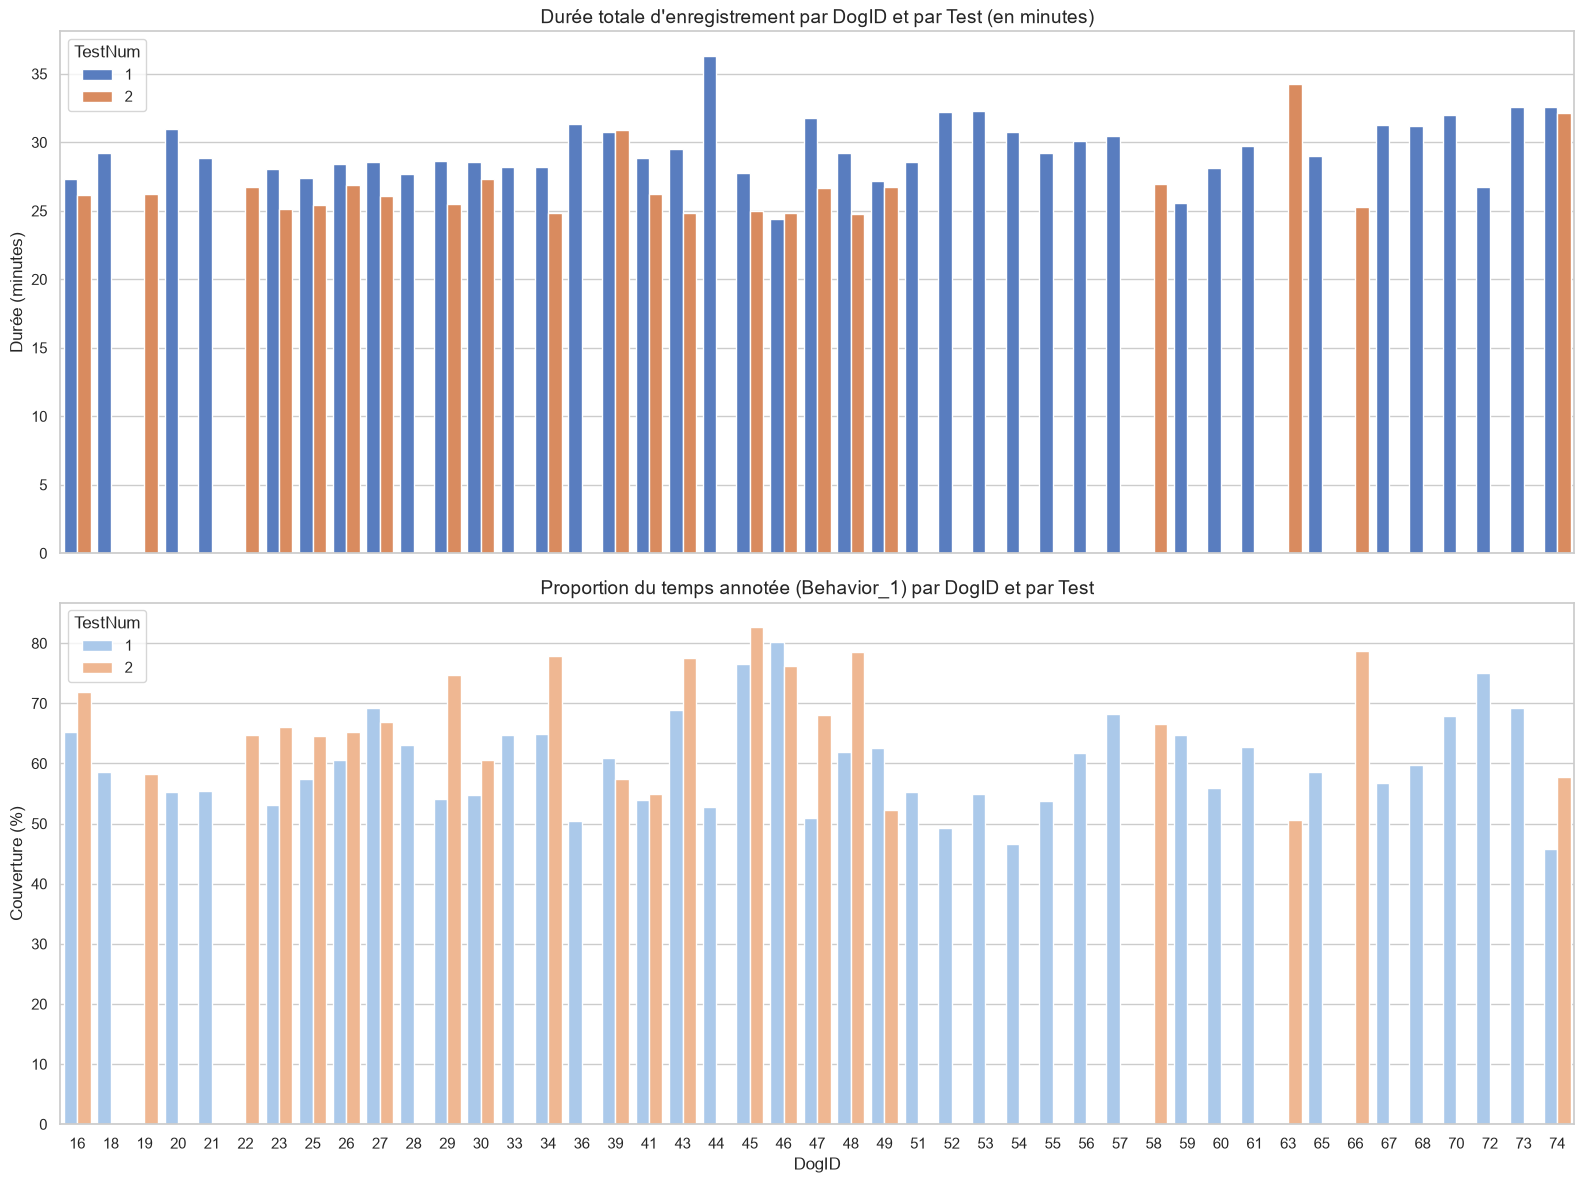

In [41]:
# 1. Calcul des métriques par chien et par test
summary_duration = df_ts_sample.groupby(['DogID', 'TestNum']).agg(
    # Le temps total en secondes (différence entre la dernière et la première valeur de t_sec)
    Temps_Total_sec=('t_sec', lambda x: x.max() - x.min()),
    
    # Comptage des lignes totales et des lignes non-nulles pour chaque comportement
    Lignes_Totales=('t_sec', 'count'),
    Lignes_B1=('Behavior_1', 'count'),
    Lignes_B2=('Behavior_2', 'count'),
    Lignes_B3=('Behavior_3', 'count')
).reset_index()

# 2. Conversion en minutes et calcul des pourcentages de couverture
summary_duration['Temps_Total_min'] = (summary_duration['Temps_Total_sec'] / 60).round(2)

summary_duration['Couverture_B1 (%)'] = (summary_duration['Lignes_B1'] / summary_duration['Lignes_Totales'] * 100).round(2)
summary_duration['Couverture_B2 (%)'] = (summary_duration['Lignes_B2'] / summary_duration['Lignes_Totales'] * 100).round(2)
summary_duration['Couverture_B3 (%)'] = (summary_duration['Lignes_B3'] / summary_duration['Lignes_Totales'] * 100).round(2)

# 3. Affichage du tableau propre
colonnes_affichage = [
    'DogID', 'TestNum', 'Temps_Total_min', 
    'Couverture_B1 (%)', 'Couverture_B2 (%)', 'Couverture_B3 (%)'
]
df_coverage = summary_duration[colonnes_affichage]

print("=== Résumé des enregistrements et de la couverture des labels ===")
display(df_coverage)


# 4. Visualisation pour repérer immédiatement les inégalités
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# Graphique du haut : Temps total par chien
sns.barplot(
    data=summary_duration, 
    x='DogID', y='Temps_Total_min', hue='TestNum', 
    ax=axes[0], palette='muted'
)
axes[0].set_title("Durée totale d'enregistrement par DogID et par Test (en minutes)", fontsize=14)
axes[0].set_ylabel("Durée (minutes)")

# Graphique du bas : Couverture de Behavior_1 (le comportement principal)
sns.barplot(
    data=summary_duration, 
    x='DogID', y='Couverture_B1 (%)', hue='TestNum', 
    ax=axes[1], palette='pastel'
)
axes[1].set_title("Proportion du temps annotée (Behavior_1) par DogID et par Test", fontsize=14)
axes[1].set_ylabel("Couverture (%)")
axes[1].set_xlabel("DogID")

plt.tight_layout()
plt.show()